## Rolls out CCM in the circle example


1. Train CCM via: ""python3 garage/examples/torch/multi_env_CL.py""

where the command is run from the root directory.

In [1]:
import os
os.chdir("../..")
os.getcwd()

'/Users/paulnitschke/Desktop/projects/geo_meta_rl'

In [52]:
import torch
S_0 = torch.tensor([0.0, 0.0])
R = lambda s,z: -torch.norm(s-z)**2
T = lambda s,a: s + a
Z_0 = torch.tensor([1.0, 0.0])

pi_star = lambda s: 0.1*(Z_0-s)
rotation_matrix = lambda theta: torch.tensor([
    [torch.cos(theta), -torch.sin(theta)],
    [torch.sin(theta),  torch.cos(theta)]
])


def rollout(pi, z, lg, kg, n_steps = 15):

    s = S_0
    states, rewards = [], []
    for _ in range(n_steps):
        s_tilde = lg @ s
        a = pi(s_tilde)
        a_tilde = kg @ a
        s_prime = T(s, a_tilde)
        r = R(s_prime, z)
        s = s_prime
        states.append((s))
        rewards.append(r)
    states_np = torch.stack(states).numpy()
    rewards_np = torch.stack(rewards).numpy()
    
    return states_np, rewards_np

THETA = torch.tensor(0.2)
JG = torch.tensor(rotation_matrix(THETA), dtype=torch.float32)
Z_0_prime = JG @ Z_0

lg = torch.tensor(rotation_matrix(THETA), dtype=torch.float32)
lg_inv = torch.linalg.inv(lg)
kg = torch.tensor(rotation_matrix(THETA), dtype=torch.float32)

traj_base, rewards_base = rollout(pi_star, Z_0, lg_inv, kg)

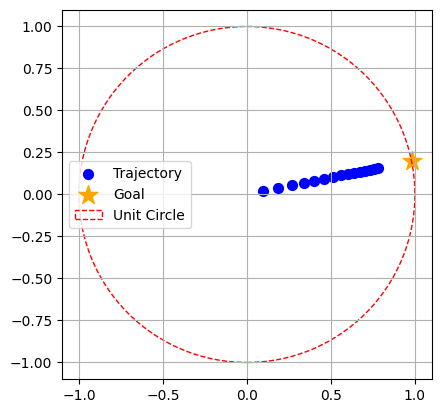

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots()

ax.scatter(traj_base[:,0], traj_base[:,1], marker='o', s=50, c='blue', label="Trajectory")
ax.scatter(Z_0_prime[0], Z_0_prime[1], marker='*', s=200, c='orange', label="Goal")

unit_circle = patches.Circle((0, 0), radius=1, fill=False, color='red', linestyle='--', label="Unit Circle")
ax.add_patch(unit_circle)

ax.set_aspect('equal')  # ensures circle is not distorted
ax.grid()
ax.legend()
plt.show()


In [3]:
# Load the policy
import os
import pandas
from garage.experiment import Snapshotter
from garage.experiment.task_sampler import SetTaskSampler
from garage.envs import GymEnv, normalize
from garage.envs.point_env import PointEnv
from garage.torch.algos.custom.CLMeta import PEARLWorker
from garage.experiment.meta_evaluator import MetaEvaluator

def rollout_method(experiment_dir: str,
                   num_train_tasks: int=4,
                    num_test_tasks=20
                    ):
    """Loads a trained agent from an experiment and performs meta train and test rollouts."""

    snapshotter = Snapshotter()
    data = snapshotter.load(experiment_dir)
    policy = data['algo'].policy
    experiment_data_path = os.path.join(experiment_dir, "experiment.json")
    experiment_data = pandas.read_json(experiment_data_path)

    # You can also access other components of the experiment
    env = data['env']

    progress_csv_path = os.path.join(experiment_dir, 'progress.csv')
    # progress_df = pd.read_csv(progress_csv_path)

    # Sample trajectories on training tasks.
    print("Sampling train trajectories...")
    worker_args = dict(deterministic=True, accum_context=True)
    env_sampler = SetTaskSampler(
        PointEnv,
        wrapper=lambda env, _: normalize(
            env))
    train_envs = env_sampler.sample(num_train_tasks, sampling_mode="uniform")

    meta_evaluator = MetaEvaluator(test_tasks=train_envs,
                                worker_class=PEARLWorker,
                                worker_args=worker_args,
                                n_exploration_eps=10,
                                n_test_tasks=2,
                                return_task_embeddings=True,
                                log_wandb=False)

    train_trajs, train_task_embeddings = meta_evaluator.evaluate(algo=data['algo'])


    # Sample trajectories on testing tasks.
    print("Sampling test trajectories...")
    worker_args = dict(deterministic=True, accum_context=True)
    env_sampler = SetTaskSampler(
        PointEnv,
        wrapper=lambda env, _: normalize(
            env),
            )
    test_envs = env_sampler.sample(num_test_tasks, sampling_mode="linspace")

    meta_evaluator = MetaEvaluator(test_tasks=test_envs,
                                worker_class=PEARLWorker,
                                worker_args=worker_args,
                                n_exploration_eps=10,
                                n_test_tasks=num_test_tasks,
                                return_task_embeddings=True,
                                log_wandb=False)

    test_trajs, test_task_embeddings = meta_evaluator.evaluate(algo=data['algo'])

    return train_envs, test_envs, train_trajs, train_task_embeddings, test_trajs, test_task_embeddings

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
circle_radius = 1


def plot_trajs_on_circle(trajs, marker_trajs, title):
    # Create a colormap and normalizer
    cmap = plt.cm.hsv  # Use the hsv colormap
    norm = Normalize(vmin=0, vmax=2 * np.pi)

    # Generate points for the circle
    angles = np.linspace(0, 2 * np.pi, 500)
    x_circle = circle_radius * np.cos(angles)
    y_circle = circle_radius * np.sin(angles)

    # Create the figure and axis
    fig = plt.figure(figsize=(12, 12))  # Increase figure size for wider space around the circle
    ax = fig.add_subplot(111)

    # Set the fixed size for the circle area (8x8 inches)
    circle_size_inches = 8
    fig_width, fig_height = fig.get_size_inches()

    # Calculate the position for the circle to take up exactly 8x8 inches
    left_margin = (fig_width - circle_size_inches) / 2 / fig_width
    bottom_margin = (fig_height - circle_size_inches) / 2 / fig_height
    ax_width = circle_size_inches / fig_width
    ax_height = circle_size_inches / fig_height

    ax.set_position([left_margin, bottom_margin, ax_width, ax_height])  # Adjust axis position

    # Set fixed aspect ratio and limits
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-circle_radius * 1.2, circle_radius * 1.2)  # Add more padding around the circle
    ax.set_ylim(-circle_radius * 1.2, circle_radius * 1.2)  # Add more padding around the circle

    # Add grid in the background
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, color='gray')

    # Plot the circle with continuous color
    for i in range(len(angles) - 1):
        ax.plot(x_circle[i:i + 2], y_circle[i:i + 2], color=cmap(norm(angles[i])), linewidth=2, alpha=0.4)

    # Plot trajectories
    for task_traj in trajs:
        goal_x, goal_y = task_traj.env_infos["task"][0]["goal"]
        goal_angle = (np.arctan2(goal_y, goal_x) + 2 * np.pi) % (2 * np.pi)

        goal_color = cmap(norm(goal_angle))
        ax.plot(task_traj.observations[:, 0], task_traj.observations[:, 1], c=goal_color, alpha=0.7)

    # Plot markers for task goals
    for marker_traj in marker_trajs:
        goal_x, goal_y = marker_traj.env_infos["task"][0]["goal"]
        goal_angle = (np.arctan2(goal_y, goal_x) + 2 * np.pi) % (2 * np.pi)

        goal_color = cmap(norm(goal_angle))
        ax.scatter(goal_x, goal_y, color=goal_color, marker='x', s=100)

    ax.scatter([], [], color='black', marker='x', label='Task Goal')
    ax.plot([], [], color='black', label='Task Trajectory')

    # Turn off the axis
    ax.axis('off')

    # Add title
    plt.title(title, fontsize=20)
    ax.legend(ncol=2, loc='lower center', bbox_to_anchor=(0.48, -0.05), frameon=False, fontsize=18)
    # Save the plot
    plt.show()

## Sample trajectories with CCM and Pearl

In [43]:
CCM_EXPERIMENT_DIR = os.path.join("data/local/experiment", "CL_point_env_2")

train_envs_CCM, test_envs_CCM, train_trajs_CCM, train_task_embeddings_CCM, test_trajs_CCM, test_task_embeddings_CCM = rollout_method(experiment_dir=CCM_EXPERIMENT_DIR,
                                                                                                      num_train_tasks=4, 
                                                                                                      num_test_tasks=20)



Failed to import TF-Keras. Please note that TF-Keras is not installed by default when you install TensorFlow Probability. This is so that JAX-only users do not have to install TensorFlow or TF-Keras. To use TensorFlow Probability with TensorFlow, please install the tf-keras or tf-keras-nightly package.
This can be be done through installing the tensorflow-probability[tf] extra.




Failed to import TF-Keras. Please note that TF-Keras is not installed by default when you install TensorFlow Probability. This is so that JAX-only users do not have to install TensorFlow or TF-Keras. To use TensorFlow Probability with TensorFlow, please install the tf-keras or tf-keras-nightly package.
This can be be done through installing the tensorflow-probability[tf] extra.


Sampling train trajectories...


Failed to import TF-Keras. Please note that TF-Keras is not installed by default when you install TensorFlow Probability. This is so that JAX-only users do not have to install TensorFlow or TF-Kera

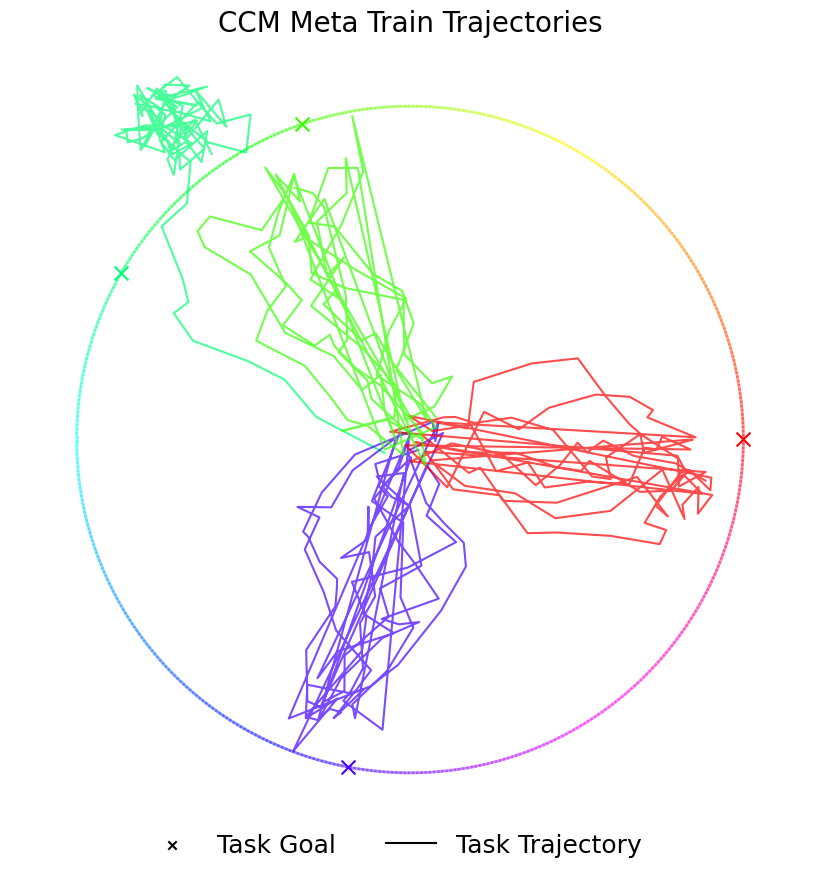

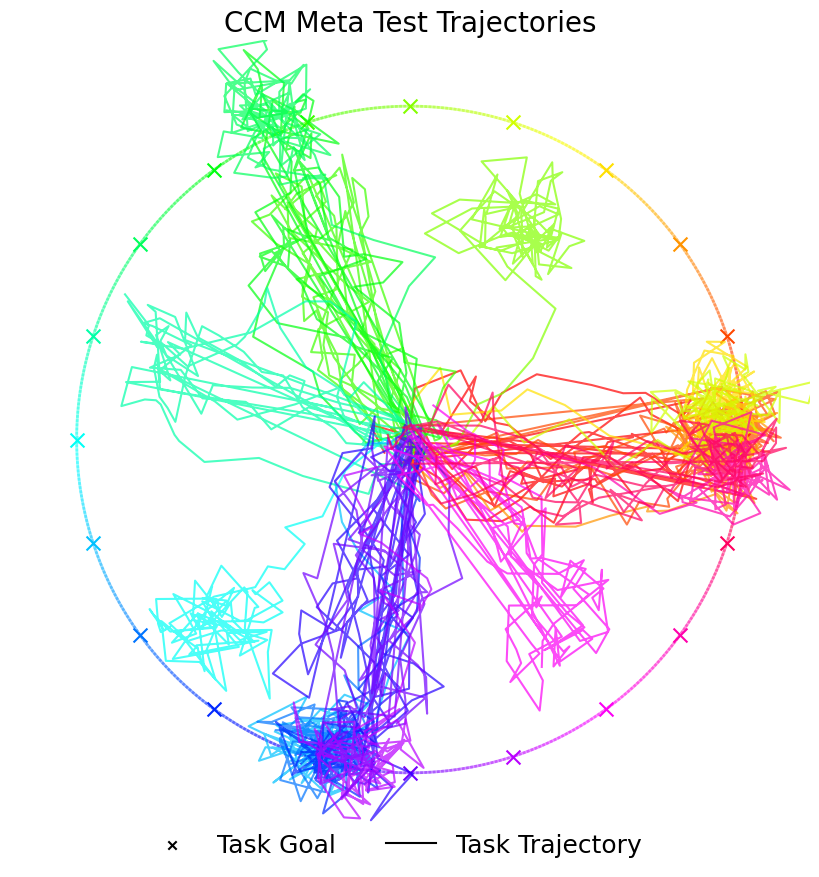

In [45]:
plot_trajs_on_circle(train_trajs_CCM, train_trajs_CCM, "CCM Meta Train Trajectories")
plot_trajs_on_circle(test_trajs_CCM, test_trajs_CCM, "CCM Meta Test Trajectories")

## Plot regret as a function of distance to training task.

Garage does not stop sampling once the episode is done, only once the maximal number of steps is reached. Thereby, an agent walking close to the goal position and staying there will have a lower regret than an agent repeatedly walking into the goal position and then being teleported back into the origin. So we strip all trajectories once the agent is "close" to the goal.

In [ ]:
REWARD_DONE_THRESHOLD=-0.1

def trim_rewards(arr, threshold):
    """
    Return rewards up to (but not including) the first value above the done threshold.
    If no value is above threshold, return the whole array.
    """
    for i, val in enumerate(arr):
        if val > threshold:
            return arr[:i+1]
    return arr

# Compute return of each test trajectory.
rewards_CCM_train_raw = [train_trajs_CCM[i].rewards for i in range(len(train_trajs_CCM))]
rewards_CCM_train_trimmed = [trim_rewards(rewards_CCM_train_raw[i], REWARD_DONE_THRESHOLD) for i in range(len(rewards_CCM_train_raw))]
returns_CCM_train = [np.sum(rewards_CCM_train_trimmed[i]) for i in range(len(rewards_CCM_train_trimmed))]

rewards_CCM_test_raw = [test_trajs_CCM[i].rewards for i in range(len(test_trajs_CCM))]
rewards_CCM_test_trimmed = [trim_rewards(rewards_CCM_test_raw[i], REWARD_DONE_THRESHOLD) for i in range(len(rewards_CCM_test_raw))]
returns_CCM_test = [np.sum(rewards_CCM_test_trimmed[i]) for i in range(len(rewards_CCM_test_trimmed))]

In [103]:
train_goals_CCM = [env._task['goal'] for env in train_envs_CCM]
test_goals_CCM = [env._task['goal'] for env in test_envs_CCM]

def compute_min_angles(test_goals, train_goals):
    """
    For each vector in test_goals, compute the smallest angle to any vector in train_goals.
    Assumes all vectors are points on the unit circle.
    """
    min_angles = []
    for test in test_goals:
        dots = [np.dot(test, train) for train in train_goals]
        dots = np.clip(dots, -1.0, 1.0)
        angles = np.arccos(dots)
        min_angles.append(np.min(angles))
    return min_angles

distances_to_train_CCM = compute_min_angles(test_goals_CCM, train_goals_CCM)

## SAC Base Agents

In [50]:
from stable_baselines3 import SAC

base_policy_path = "data/local/experiment/2d_navigation/circle_task_geometry/task_0/policy"
SAC_model = SAC.load(base_policy_path)
goal_location_task_0 = torch.tensor([-0.7, 0.7])

In [62]:
def rollout_SAC(pi, lg, kg, goal, n_steps = 15) -> np.ndarray:
    """Rollouts a policy via hereditary geometry."""
    s = S_0
    states = []
    for _ in range(n_steps):
        s_tilde = lg @ s
        a, _ = pi.predict(s_tilde)
        a_tilde = kg @ a
        s_prime = T(s, a_tilde)
        s = s_prime
        states.append((s))

        if torch.norm(s - goal) < 0.2:
            break
    states_np = torch.stack(states).numpy()
    
    return states_np

# Load left actions (lgs) and right actions (kgs) from kernel_estimation_fixed output
left_actions_path = "data/2d_navigation/circle_task_geometry/left_actions.pt"
data = torch.load(left_actions_path)
lgs = data["lgs"]
kgs = data["kgs"]

all_trajs_SAC_base = []
all_rewards_SAC_base = []
all_goals = []
all_returns_SAC_base = []

for i in range(len(lgs)):
    lg = lgs[i]
    kg = kgs[i]
    # Goal in task i space: inv(lg) @ goal_0 = kg @ goal_0
    Z_0_prime = (kg @ goal_location_task_0.unsqueeze(-1)).squeeze(-1)
    traj_task = rollout_SAC(SAC_model, lg, kg, goal=Z_0_prime)
    rewards = -np.linalg.norm(traj_task - Z_0_prime.numpy(), axis=-1)
    all_trajs_SAC_base.append(traj_task)
    all_goals.append(Z_0_prime.numpy())
    all_rewards_SAC_base.append(rewards)
    all_returns_SAC_base.append(np.sum(rewards).item())

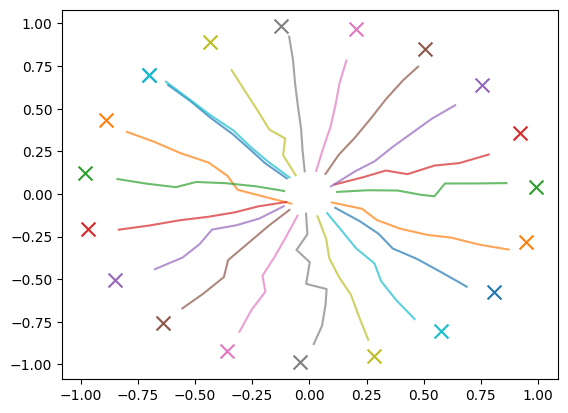

In [63]:
for traj, goal in zip(all_trajs_SAC_base, all_goals):
    plt.plot(traj[:,0], traj[:,1], alpha=0.7)
    plt.scatter(goal[0], goal[1], marker='x', s=100)

## Final plot

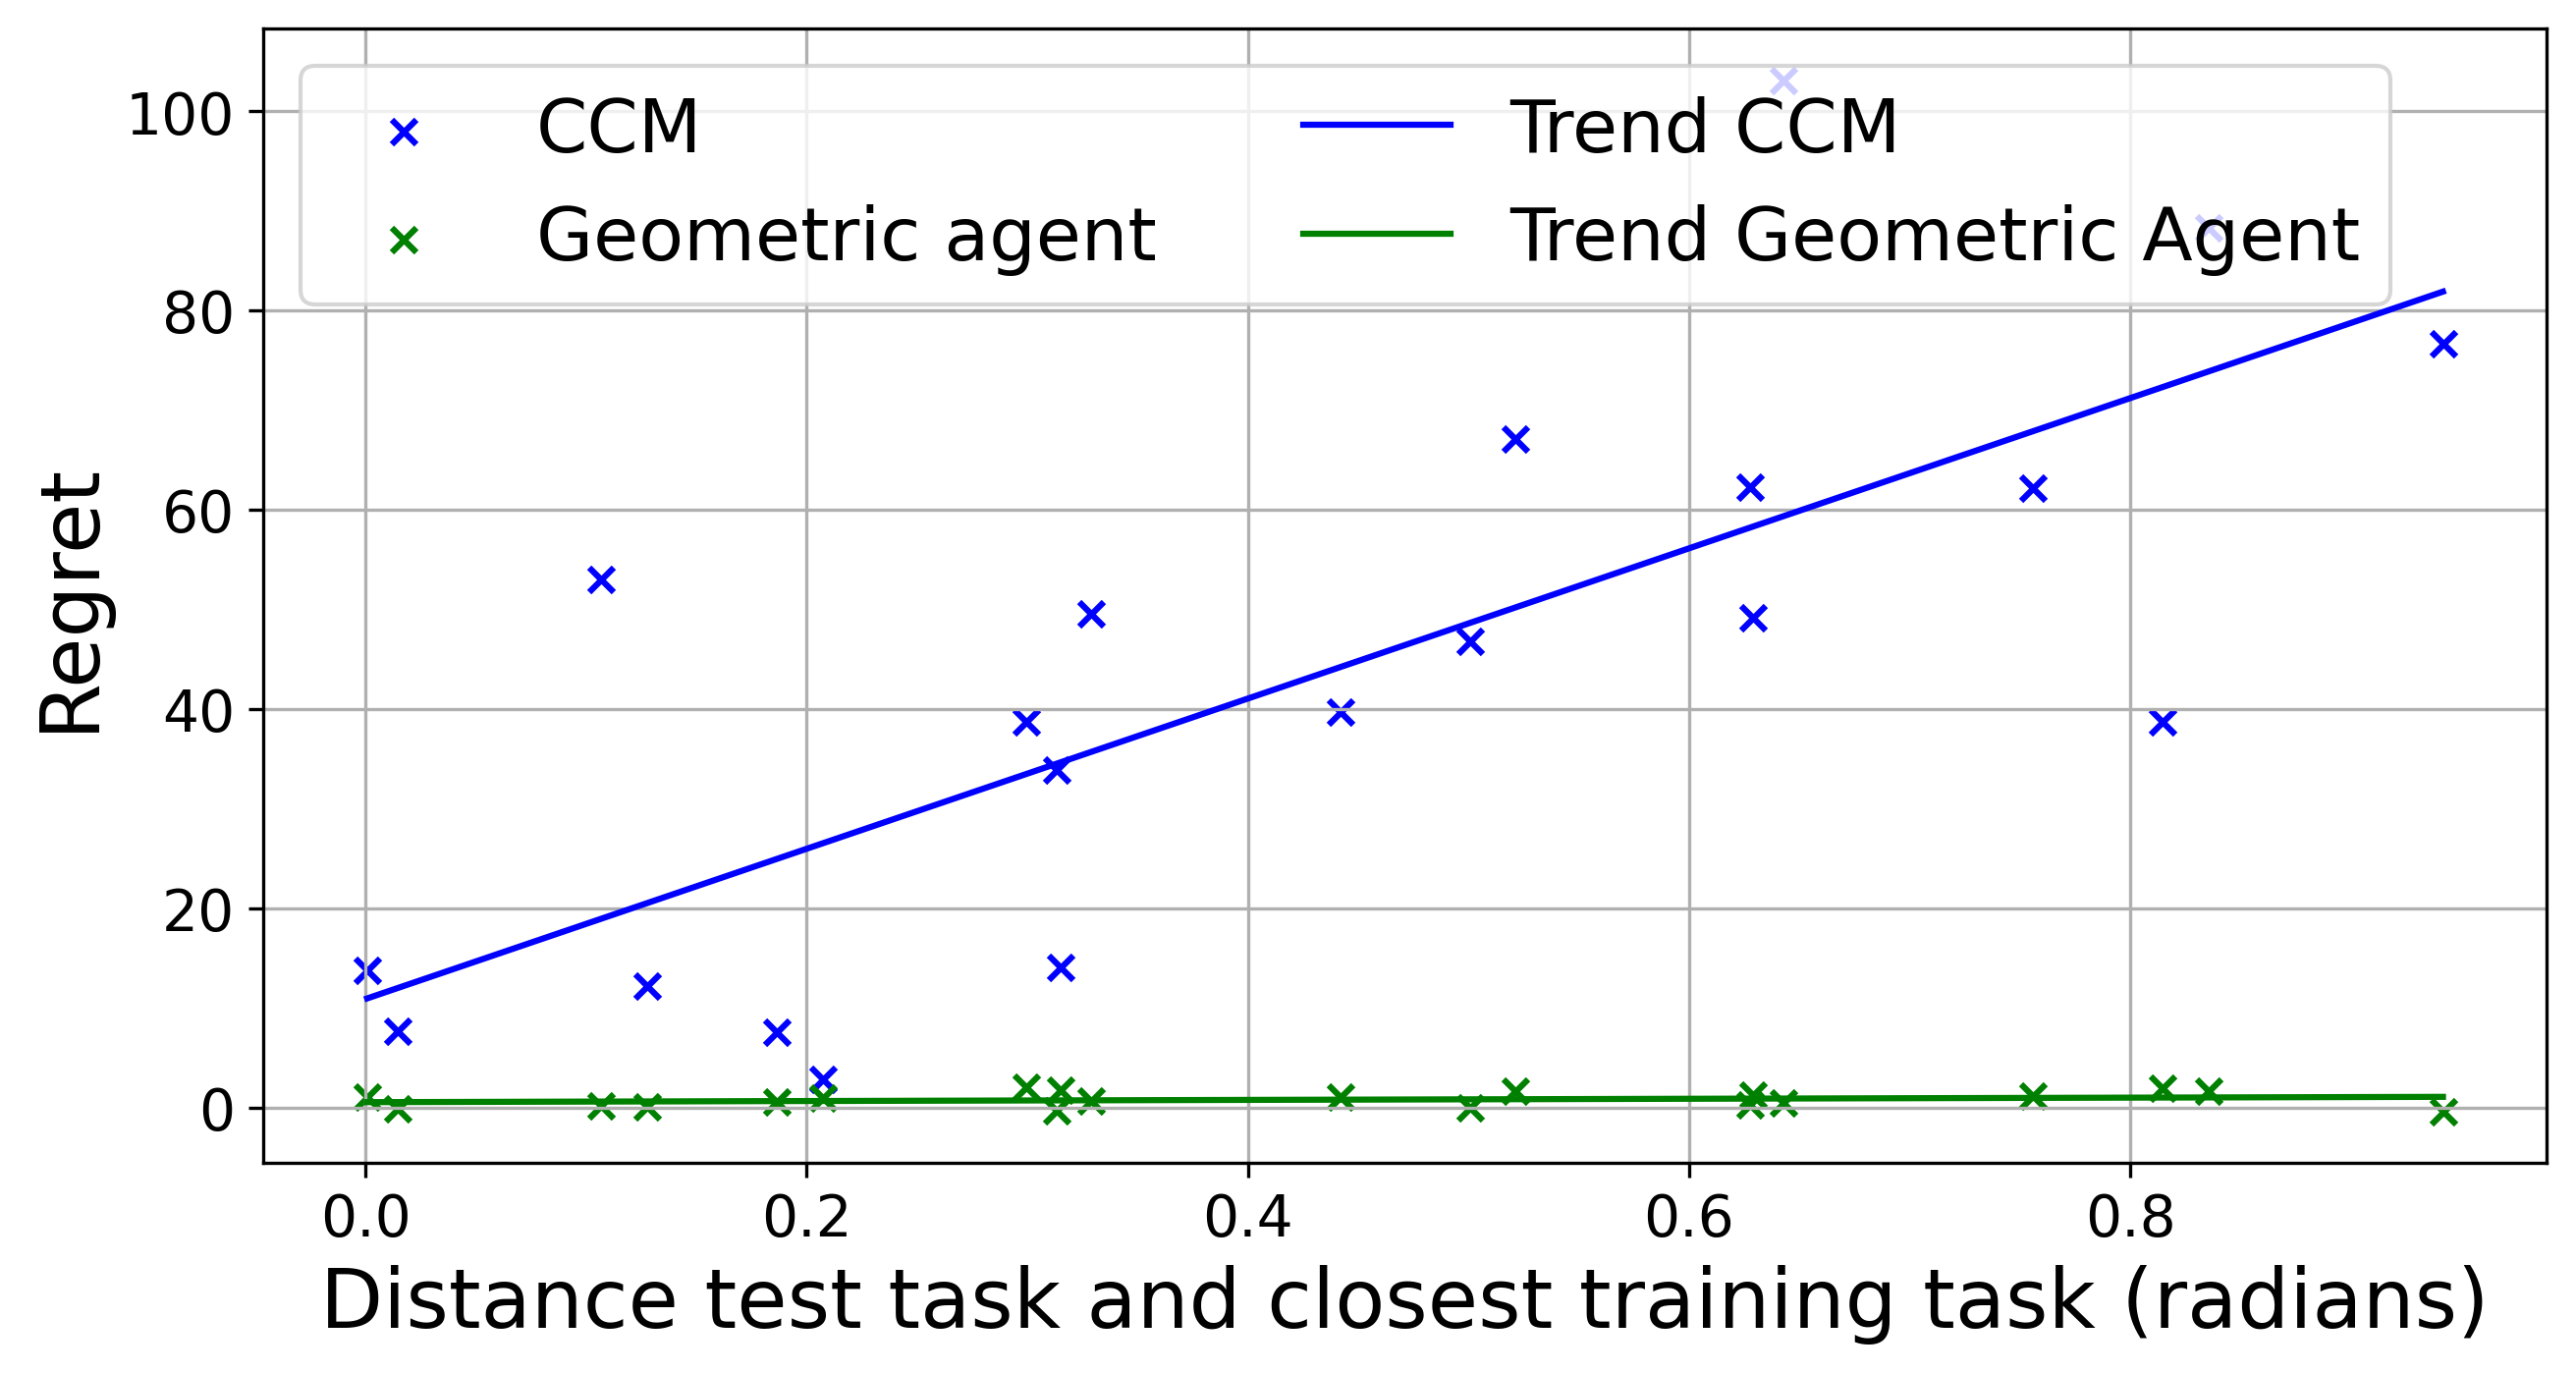

In [ ]:
from constants import LABEL_FONT_SIZE, TICK_SIZE, FIG_HEIGHT, DPI
COLOR_CCM = "blue"
COLOR_PEARL = "orange"
COLOR_GEO = "green"
MAX_REWARD=-3

plt.figure(figsize=(FIG_HEIGHT, 0.5*FIG_HEIGHT), dpi=DPI)

regrets_CCM_test = MAX_REWARD - np.array(returns_CCM_test)
regrets_SAC_base = MAX_REWARD - np.array(all_returns_SAC_base)

plt.scatter(distances_to_train_CCM, regrets_CCM_test, color=COLOR_CCM, label="CCM", marker="x")
plt.scatter(distances_to_train_CCM, regrets_SAC_base, color=COLOR_GEO, label="Geometric agent", marker="x")

coeffs_CCM = np.polyfit(distances_to_train_CCM, regrets_CCM_test, 1)
fit_line_CCM = np.poly1d(coeffs_CCM)
x_line_CCM = np.linspace(min(distances_to_train_CCM), max(distances_to_train_CCM), 100)
y_line_CCM = fit_line_CCM(x_line_CCM)
plt.plot(x_line_CCM, y_line_CCM, '-', label="Trend CCM", color=COLOR_CCM)

coeffs_oracle_base = np.polyfit(distances_to_train_CCM, regrets_SAC_base, 1)
fit_line_oracle_base = np.poly1d(coeffs_oracle_base)
x_line_oracle_base = np.linspace(min(distances_to_train_CCM), max(distances_to_train_CCM), 100)
y_line_oracle_base = fit_line_oracle_base(x_line_oracle_base)
plt.plot(x_line_oracle_base, y_line_oracle_base, '-', label="Trend Geometric Agent", color=COLOR_GEO)

plt.grid()
plt.xlabel("Distance test task and closest training task (radians)", fontsize=LABEL_FONT_SIZE-4)
plt.ylabel("Regret", fontsize=LABEL_FONT_SIZE-4)
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.legend(ncols=2, fontsize=LABEL_FONT_SIZE-6, loc='upper left')
plt.savefig("regret_plot.png", dpi=DPI)
plt.show()
